# LFM Benchmark Open Inputs


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandapower.networks as pn
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from mv_secondary_network import (
    attach_secondary_trafos_to_mv_loads,
    build_trafo_to_loads,
)

DATA = ROOT / "data"
FIG_OUT = ROOT / "fig_out"
FIG_OUT.mkdir(exist_ok=True)

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "savefig.dpi": 200,
    "figure.dpi": 110,
})


def savefig(fig, name: str):
    path = FIG_OUT / name
    fig.savefig(path, bbox_inches="tight")
    print("saved:", path)


def load_result_matrix(path: Path, value_prefix: str) -> np.ndarray:
    # Load a wide CSV with hour + prefixed columns into a (24, n) array.
    df = pd.read_csv(path)
    cols = [c for c in df.columns if c.startswith(value_prefix)]
    return df[cols].to_numpy(dtype=float)

## 1. Network + common duck-curve load profiles (base case)


In [2]:
n_steps = 24
hours = np.arange(n_steps)

load_frac = pd.read_csv(DATA / "load_frac.csv")["load_frac_pu"].to_numpy(dtype=float)

FIXED_MV_BUSES = frozenset({1, 12})
net = pn.create_cigre_network_mv()
net.trafo.loc[0, "pfe_kw"] = 22
net.trafo.loc[1, "pfe_kw"] = 22
attach_secondary_trafos_to_mv_loads(net, skip_mv_buses=FIXED_MV_BUSES)
trafo_to_loads = build_trafo_to_loads(net)

base_P = pd.read_csv(DATA / "base_load_P_mw.csv")
load_cols = [int(c.split("_", 1)[1]) for c in base_P.columns if c.startswith("load_")]
all_load_p = base_P[[f"load_{i}" for i in load_cols]].copy()
all_load_p.columns = load_cols

print(f"Loads: {len(net.load)} | Transformers: {len(net.trafo)} | "
      f"Secondaries: {int((net.trafo.vn_hv_kv <= 50).sum())}")

Loads: 21 | Transformers: 16 | Secondaries: 14


saved: /Users/savvaspanagi/Library/CloudStorage/OneDrive-CyprusUniversityofTechnology/Python-Matlab - Codes/Transformer Degradation Test/5th_Try_Base_Case/Benchmark Open Inputs/fig_out/supp_base_load_profiles.png


/var/folders/th/2f9h317n53n6jdqrwm4cjwt40000gn/T/ipykernel_14861/3310945252.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


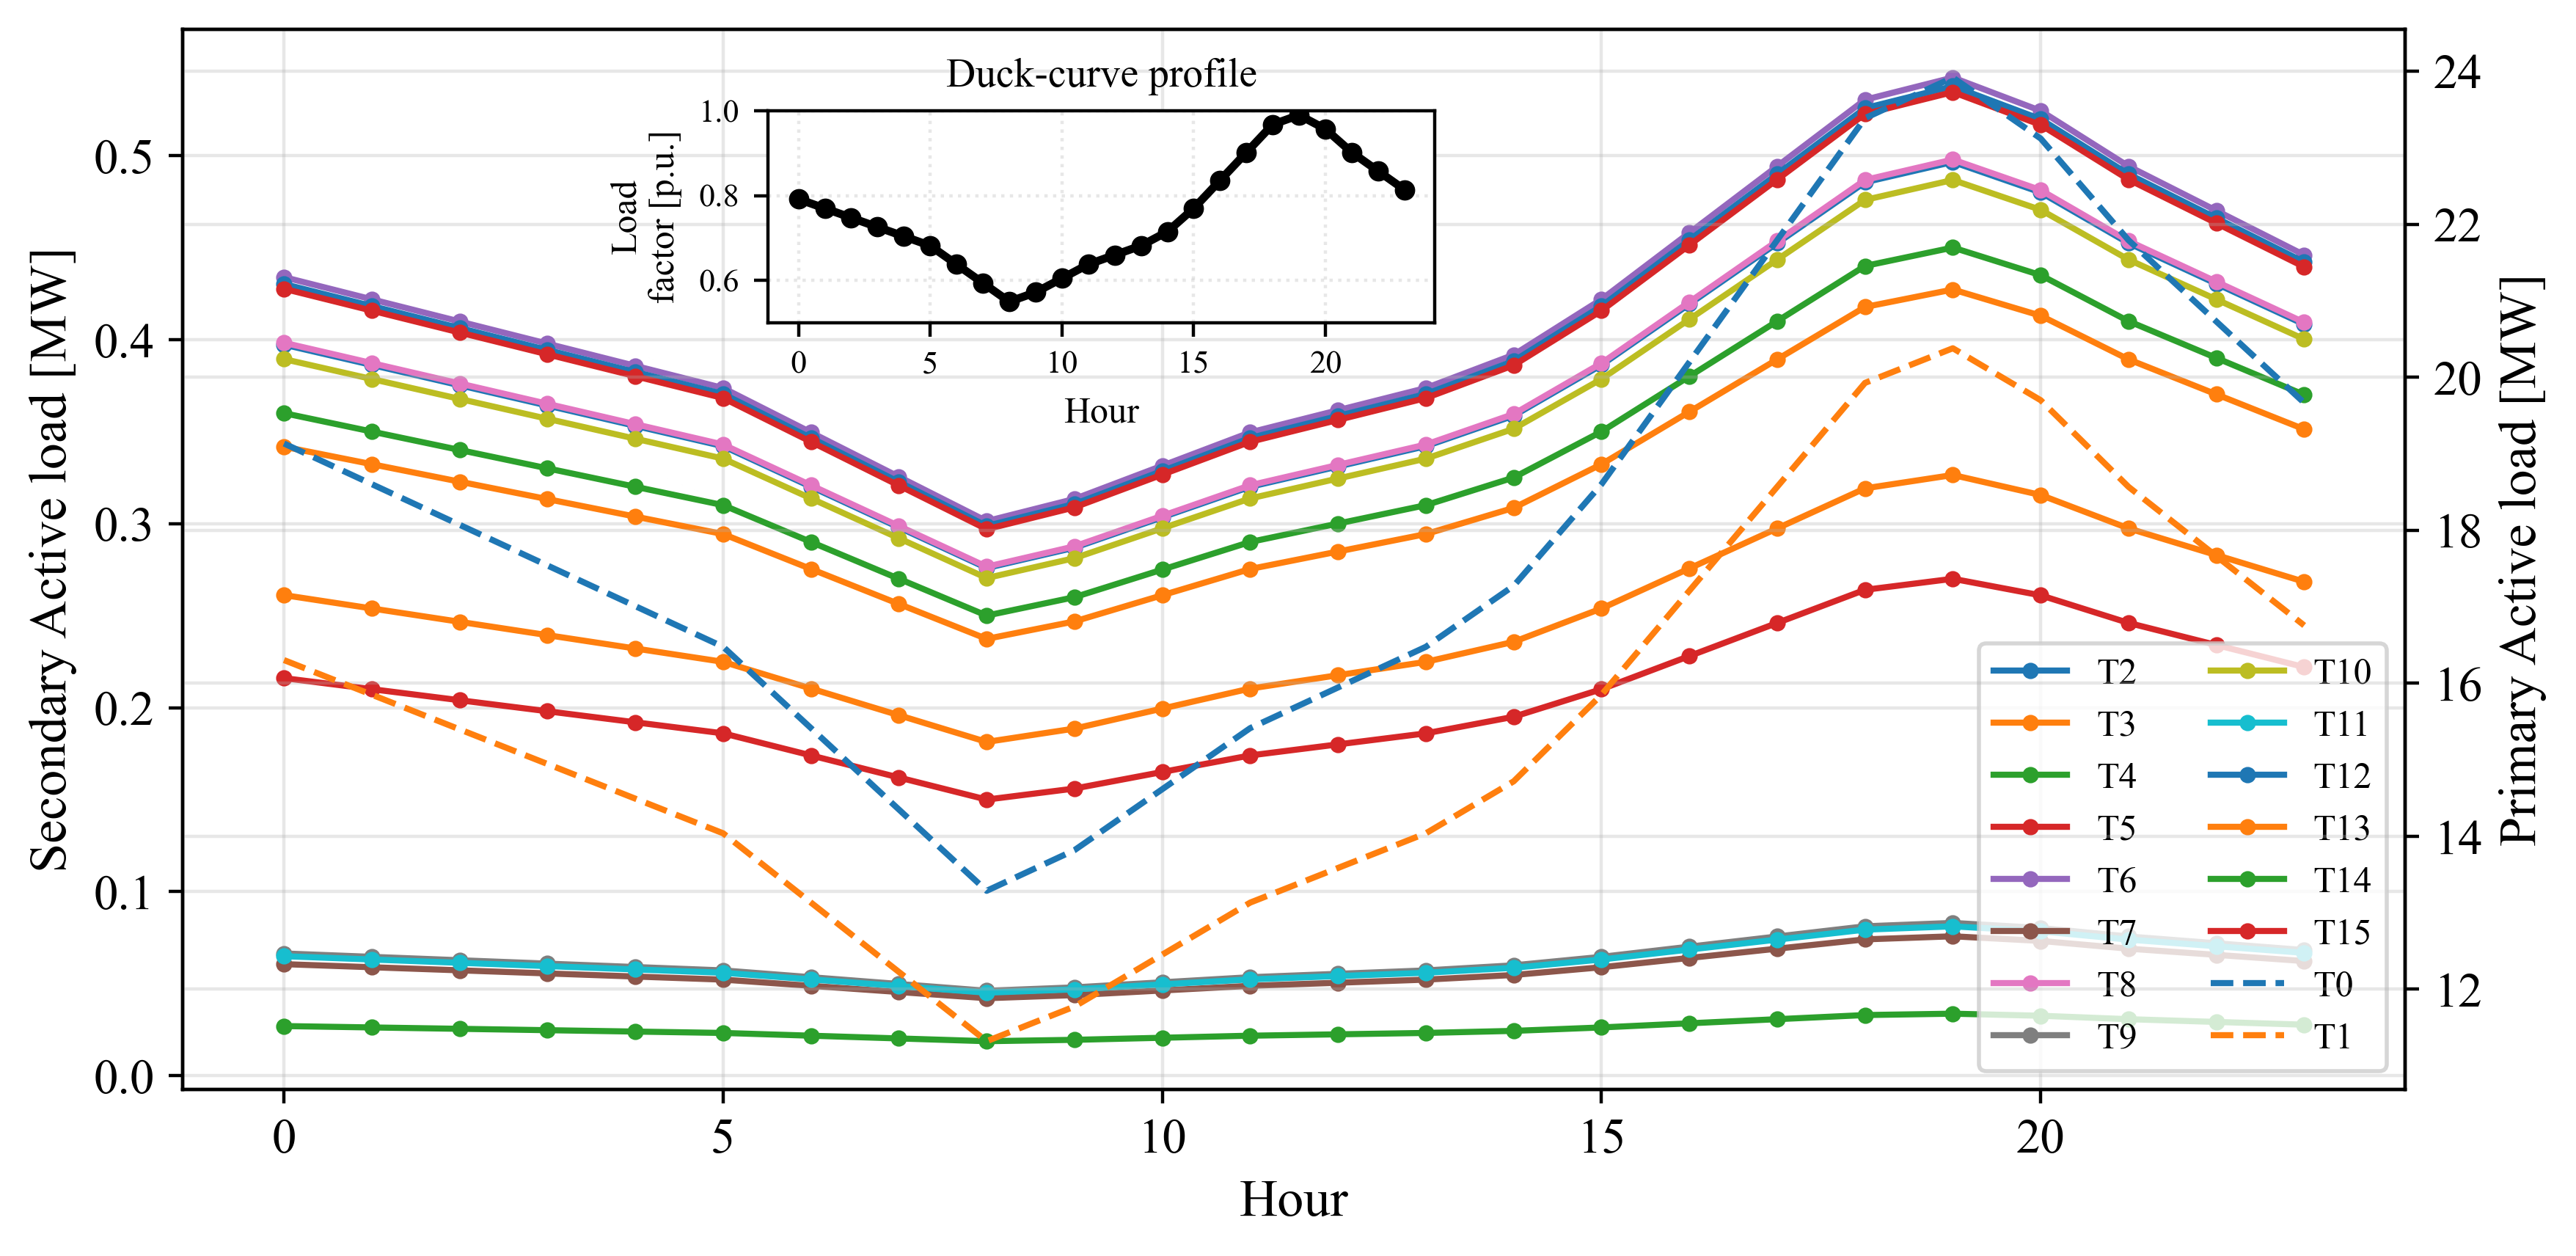

In [3]:
fig, ax_sec = plt.subplots(figsize=(9, 4.5), dpi=400)
ax_prim = ax_sec.twinx()

for t_idx, load_idxs in trafo_to_loads.items():
    if not load_idxs:
        continue
    tr = net.trafo.loc[t_idx]
    load_sum = all_load_p[load_idxs].sum(axis=1)
    label = f"T{t_idx}"
    if tr.vn_hv_kv > 50:
        ax_prim.plot(hours, load_sum, "--", ms=3, label=label)
    else:
        ax_sec.plot(hours, load_sum, "-o", ms=3, label=label)

ax_sec.set_ylabel("Secondary Active load [MW]")
ax_prim.set_ylabel("Primary Active load [MW]")
ax_sec.set_xlabel("Hour")
h1, l1 = ax_sec.get_legend_handles_labels()
h2, l2 = ax_prim.get_legend_handles_labels()
ax_sec.legend(h1 + h2, l1 + l2, fontsize=9, ncol=2, loc="lower right")

ax_inset = inset_axes(
    ax_sec, width="100%", height="100%",
    bbox_to_anchor=(0.3, 0.8, 0.3, 0.2),
    bbox_transform=ax_sec.transAxes, borderpad=2,
)
ax_inset.plot(hours, load_frac, "k-o", lw=2, ms=4)
ax_inset.set_title("Duck-curve profile", fontsize=10)
ax_inset.set_ylabel("Load\nfactor [p.u.]", fontsize=9)
ax_inset.set_xlabel("Hour", fontsize=9)
ax_inset.tick_params(labelsize=8)
ax_inset.grid(True, linestyle=":", alpha=0.3)
ax_inset.set_ylim(0.5, 1.0)

fig.tight_layout()
savefig(fig, "supp_base_load_profiles.png")
plt.show()

## 2. Wholesale energy price (Cyprus DAM, 18 July 2026)


saved: /Users/savvaspanagi/Library/CloudStorage/OneDrive-CyprusUniversityofTechnology/Python-Matlab - Codes/Transformer Degradation Test/5th_Try_Base_Case/Benchmark Open Inputs/fig_out/supp_wholesale_price.png


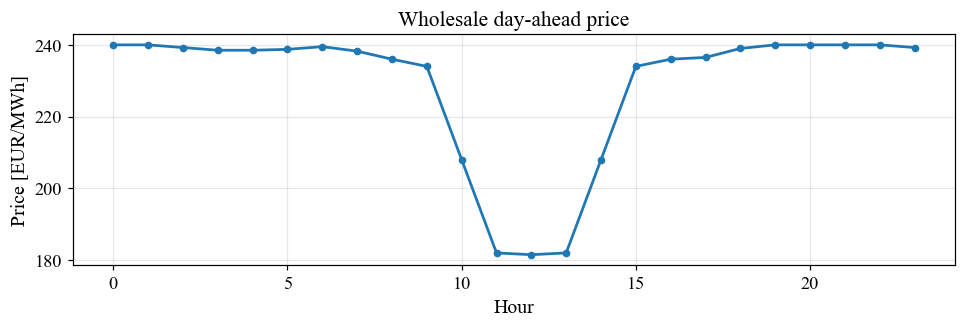

In [4]:
wholesale = pd.read_csv(DATA / "wholesale.csv")["price_eur_per_mwh"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(hours, wholesale, "-o", color="C0", ms=4, lw=1.8)
ax.set_xlabel("Hour")
ax.set_ylabel("Price [EUR/MWh]")
ax.set_title("Wholesale day-ahead price")
fig.tight_layout()
savefig(fig, "supp_wholesale_price.png")
plt.show()

## 3. Flexibility offers (bids)


   hour  bidder  secondary_idx  p_min_kw  p_max_kw  price_eur_per_mwh  \
0     0       1              0         0       120              83.22   
1     1       1              0         0       120              73.17   
2     2       1              0         0       120              85.76   
3     3       1              0         0       120              80.92   
4     4       1              0         0       120              62.83   

   pandapower_trafo_idx  
0                     2  
1                     2  
2                     2  
3                     2  
4                     2  
p_max_kw per bidder:
 bidder
1     120
2     120
3     120
4     120
5     120
6     120
7     120
8     120
9     120
10    120
11    120
12    120
13    120
14    120
saved: /Users/savvaspanagi/Library/CloudStorage/OneDrive-CyprusUniversityofTechnology/Python-Matlab - Codes/Transformer Degradation Test/5th_Try_Base_Case/Benchmark Open Inputs/fig_out/supp_fsp_bids.png


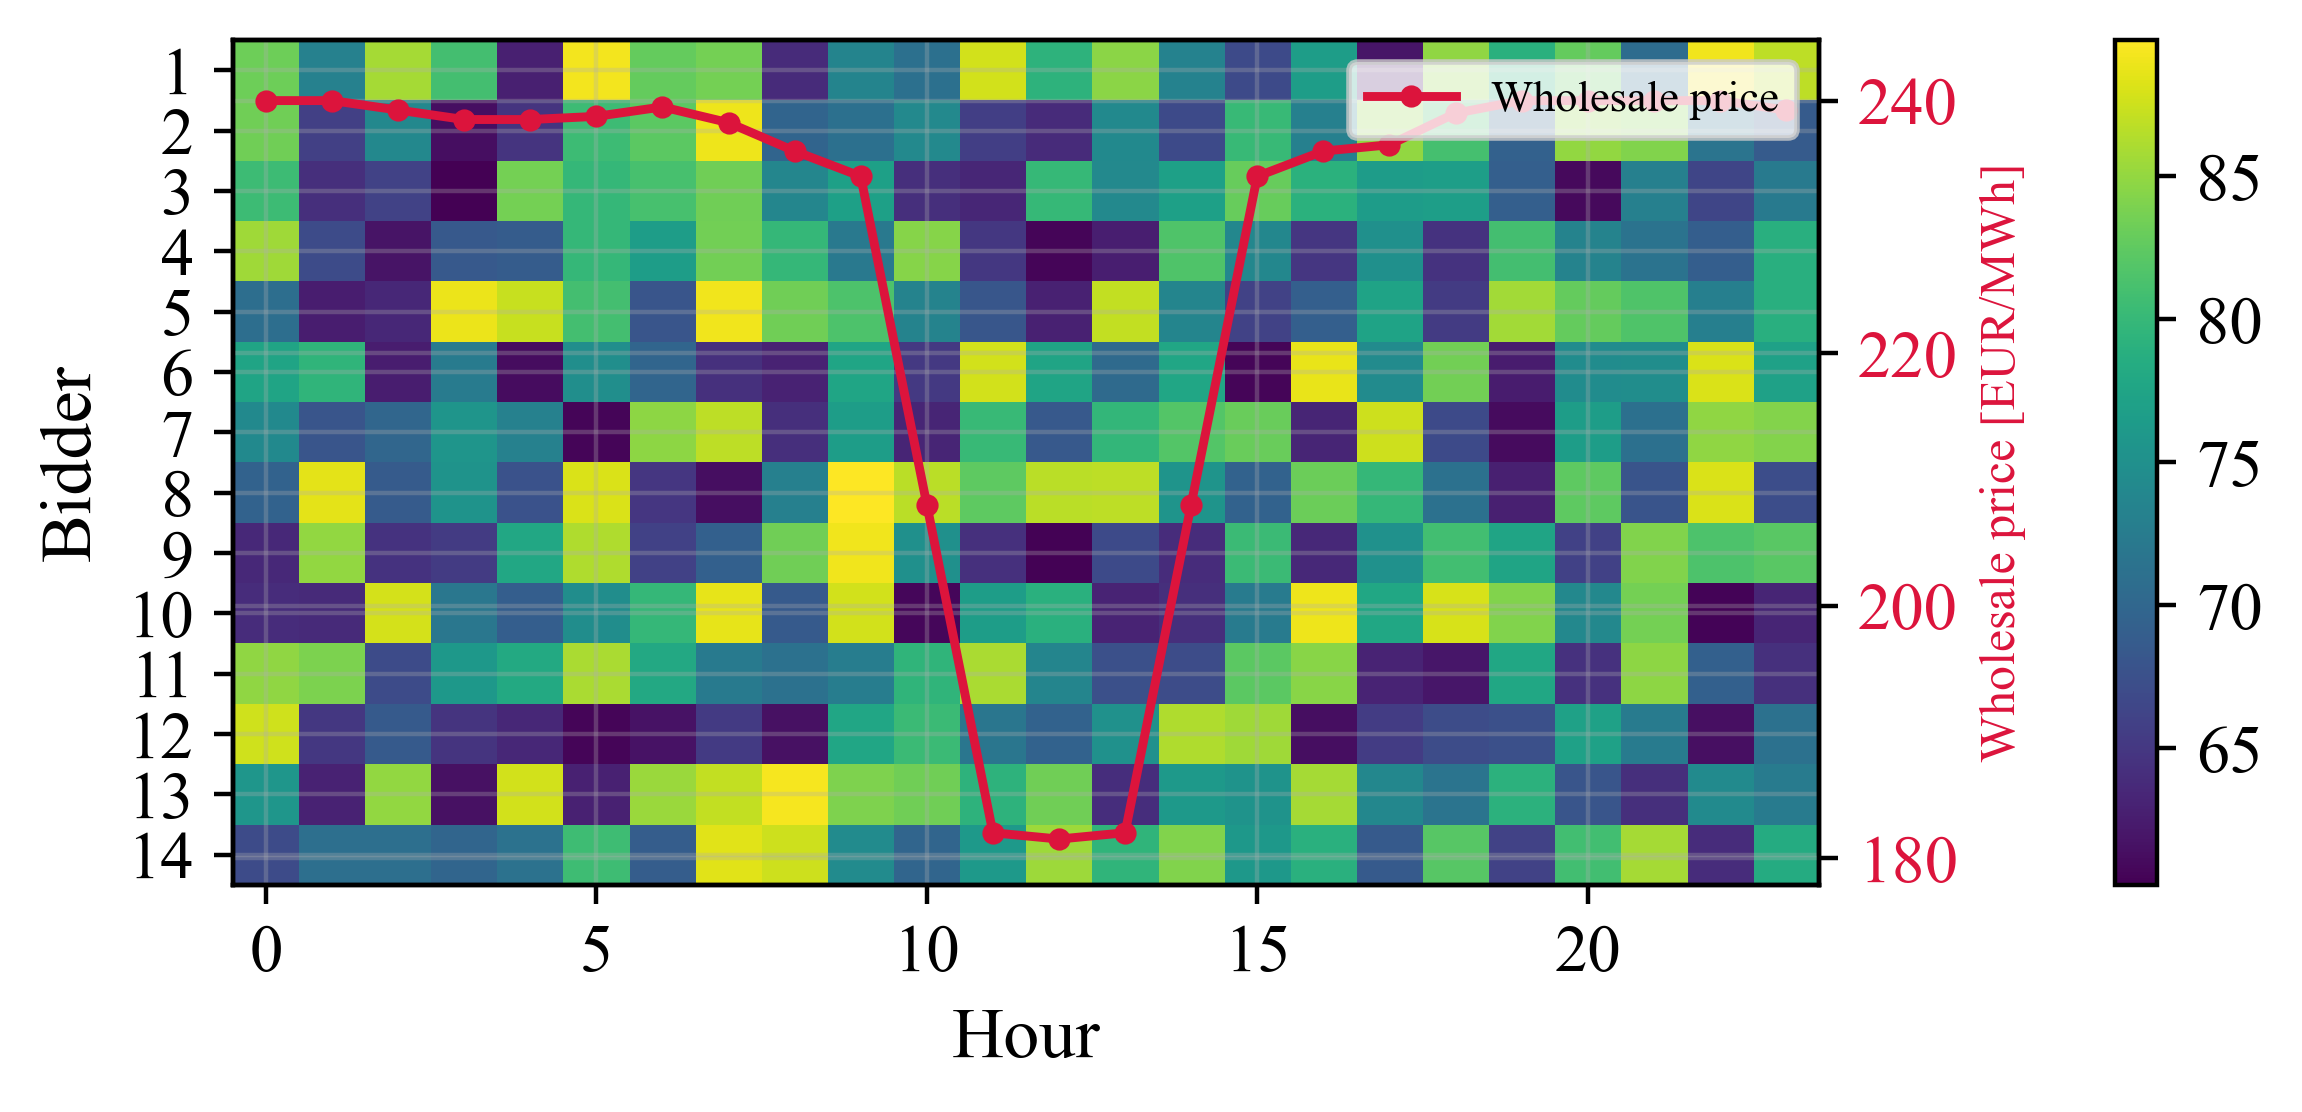

In [5]:
bids = pd.read_excel(DATA / "bids_offers.xlsx")
print(bids.head())

price_mat = bids.pivot_table(index="bidder", columns="hour", values="price_eur_per_mwh")

fig, ax = plt.subplots(figsize=(6, 3), dpi=400)
im = ax.imshow(price_mat.values, aspect="auto", cmap="viridis")
ax.set_xlabel("Hour")
ax.set_ylabel("Bidder")
ax.set_yticks(range(len(price_mat.index)))
ax.set_yticklabels(price_mat.index.astype(int))
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.15)

ax2 = ax.twinx()
ax2.plot(hours, wholesale, color="crimson", marker="o", lw=1.6, ms=3, label="Wholesale price")
ax2.set_ylabel("Wholesale price [EUR/MWh]", color="crimson", fontsize=9)
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(min(wholesale) * 0.98, max(wholesale) * 1.02)
ax2.legend(loc="upper right", fontsize=8)

print("p_max_kw per bidder:\n", bids.groupby("bidder")["p_max_kw"].first().to_string())

fig.tight_layout()
savefig(fig, "supp_fsp_bids.png")
plt.show()

## 4. Baseline operating point (base vs stress)

First run the baseline AC power flow for both days (calls `run_baseline_pf.py`), then plot voltages and loadings from the generated CSV results.


In [6]:
# Run baseline AC power flows (base + stress) using the published load profiles in data/
import run_baseline_pf

run_baseline_pf.main()

=== Running base baseline AC power flow ===
  base hour 00: Vmin=0.9231 p.u., max line=76.2%, max trafo=83.2%
  base hour 01: Vmin=0.9268 p.u., max line=73.8%, max trafo=80.6%
  base hour 02: Vmin=0.9304 p.u., max line=71.5%, max trafo=78.0%
  base hour 03: Vmin=0.9339 p.u., max line=69.1%, max trafo=75.4%
  base hour 04: Vmin=0.9375 p.u., max line=66.8%, max trafo=72.9%
  base hour 05: Vmin=0.9410 p.u., max line=64.4%, max trafo=70.3%
  base hour 06: Vmin=0.9479 p.u., max line=59.8%, max trafo=65.4%
  base hour 07: Vmin=0.9546 p.u., max line=55.3%, max trafo=60.5%
  base hour 08: Vmin=0.9612 p.u., max line=50.8%, max trafo=55.6%
  base hour 09: Vmin=0.9579 p.u., max line=53.1%, max trafo=58.0%
  base hour 10: Vmin=0.9529 p.u., max line=56.4%, max trafo=61.7%
  base hour 11: Vmin=0.9479 p.u., max line=59.8%, max trafo=65.4%
  base hour 12: Vmin=0.9444 p.u., max line=62.1%, max trafo=67.8%
  base hour 13: Vmin=0.9410 p.u., max line=64.4%, max trafo=70.3%
  base hour 14: Vmin=0.9357 p.u.

saved: /Users/savvaspanagi/Library/CloudStorage/OneDrive-CyprusUniversityofTechnology/Python-Matlab - Codes/Transformer Degradation Test/5th_Try_Base_Case/Benchmark Open Inputs/fig_out/supp_baseline_voltage_loading.png


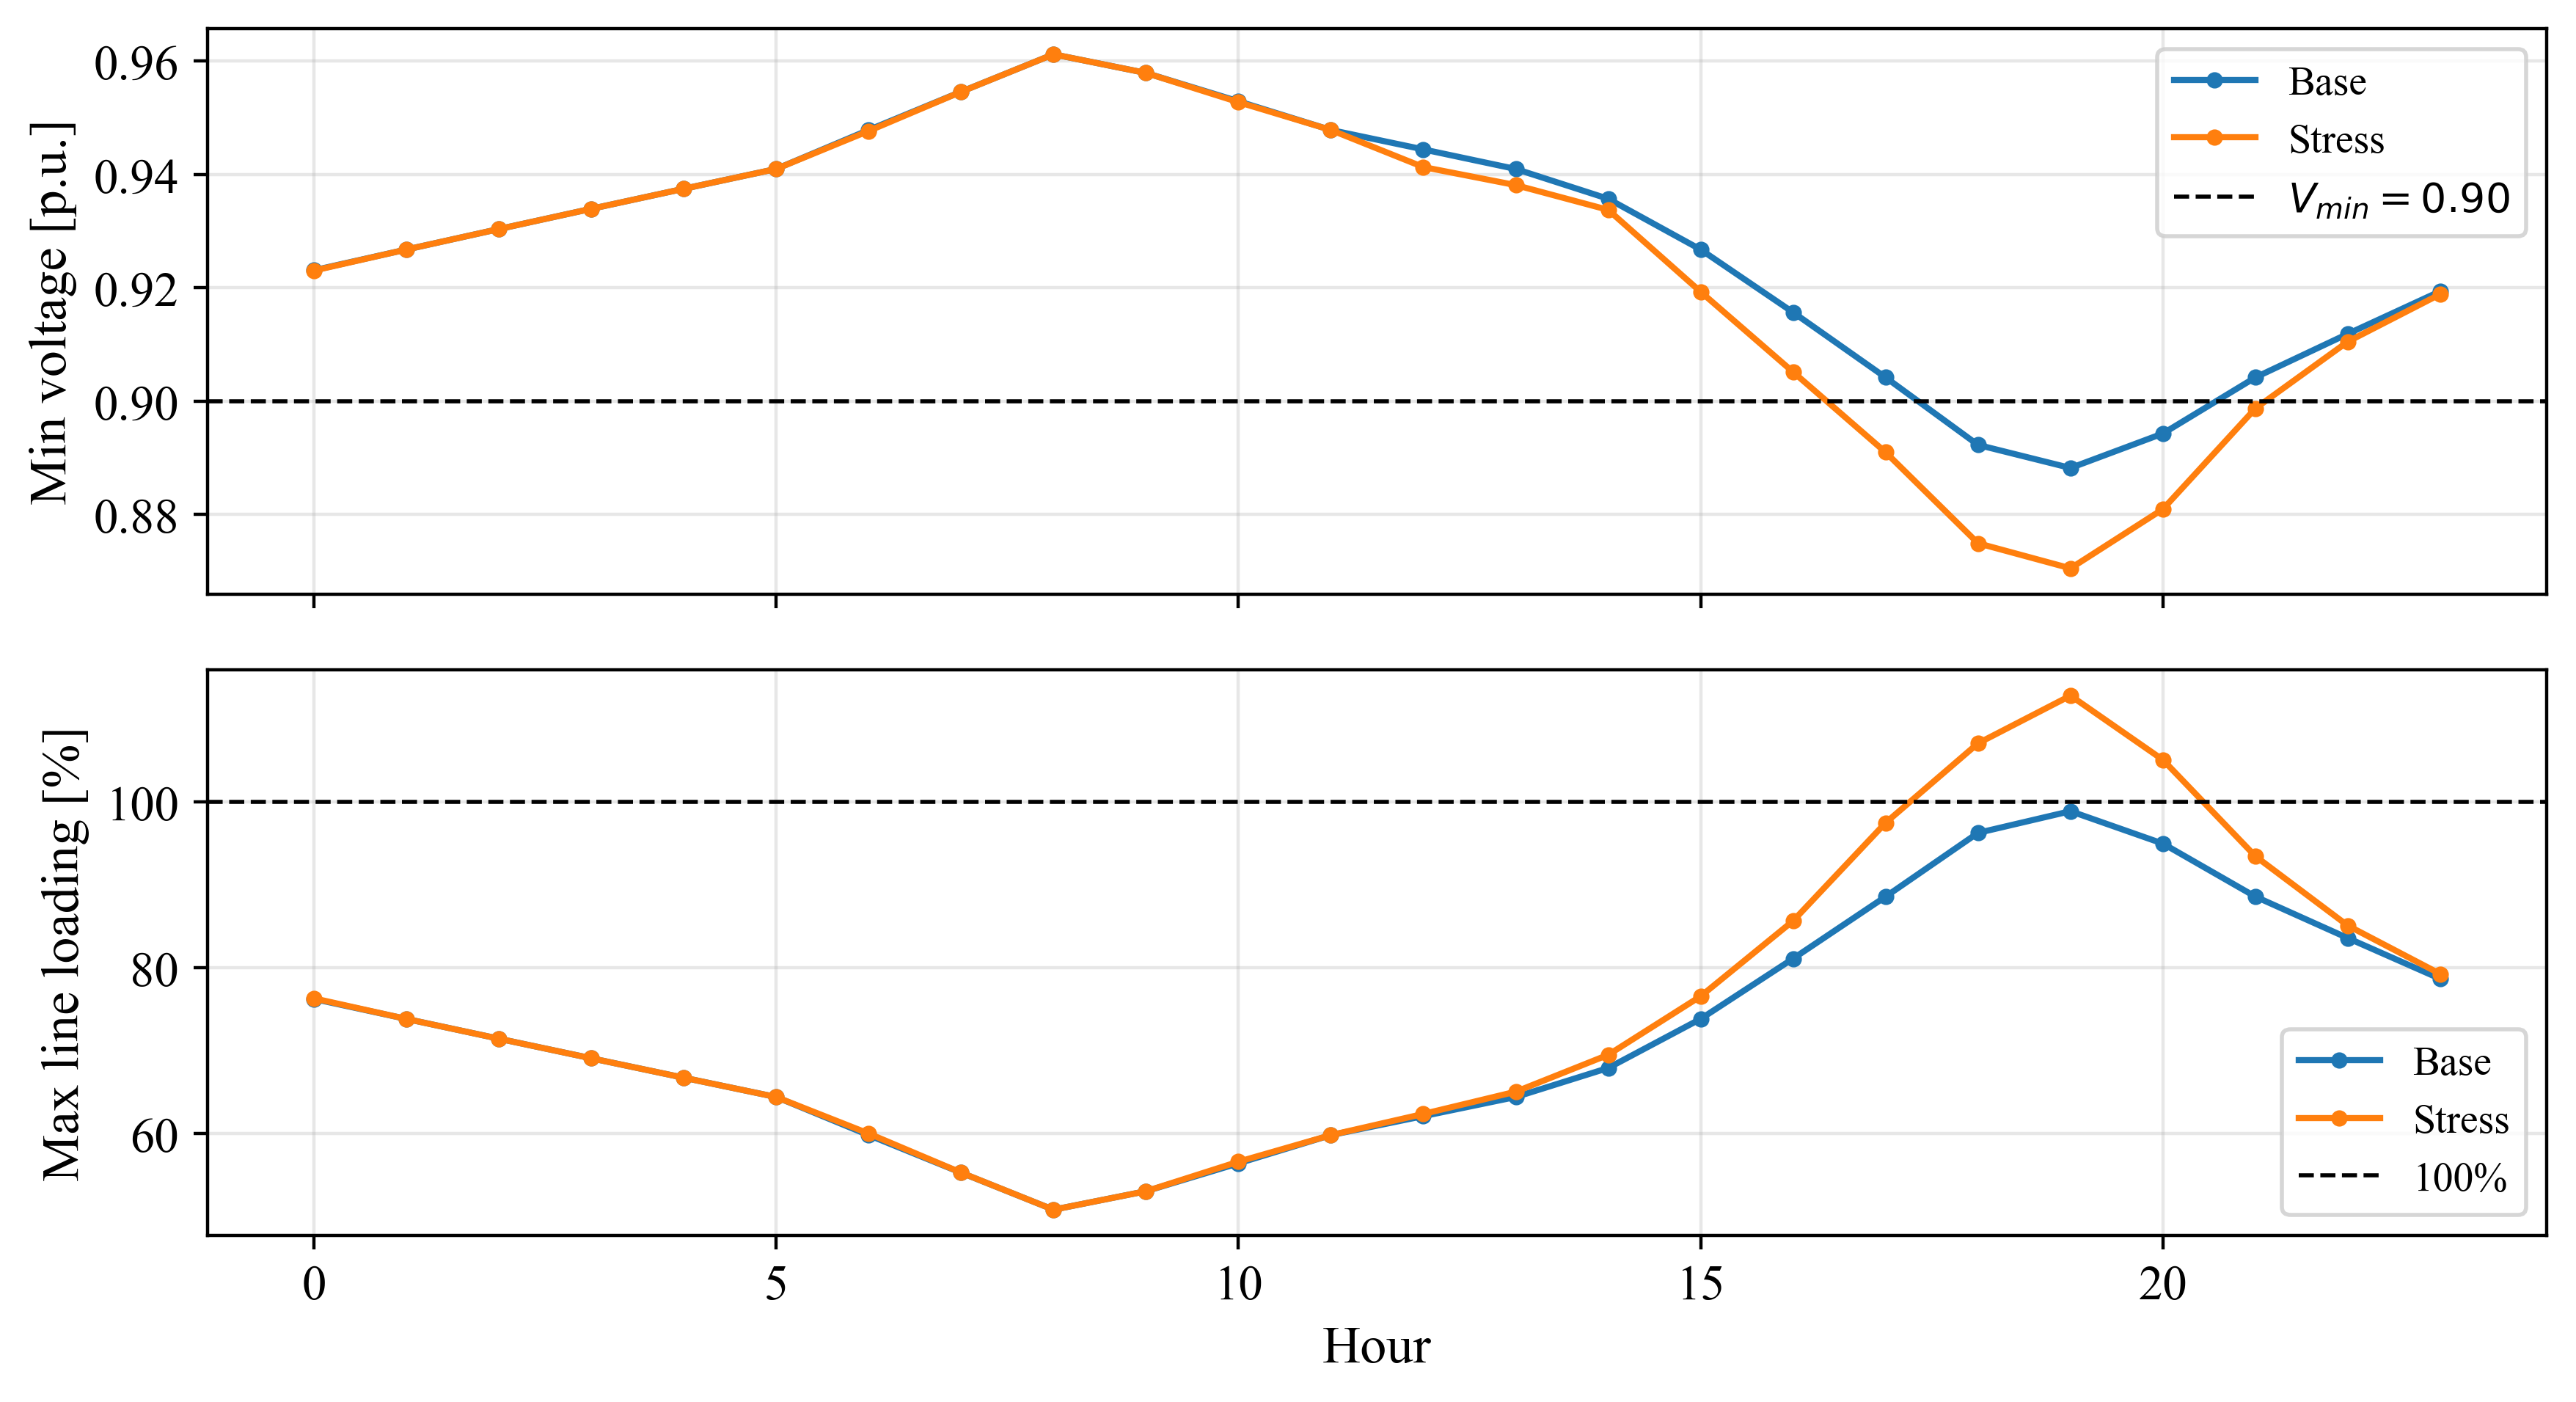

In [7]:
base_vm = pd.read_csv(ROOT / "results_base" / "vm_min.csv")["vm_min_pu"].to_numpy()
stress_vm = pd.read_csv(ROOT / "results_stress" / "vm_min.csv")["vm_min_pu"].to_numpy()
line_base = load_result_matrix(ROOT / "results_base" / "line_loading_percent.csv", "line_")
line_stress = load_result_matrix(ROOT / "results_stress" / "line_loading_percent.csv", "line_")
trafo_base = load_result_matrix(ROOT / "results_base" / "trafo_loading_percent.csv", "trafo_")
trafo_stress = load_result_matrix(ROOT / "results_stress" / "trafo_loading_percent.csv", "trafo_")

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, dpi=400)
axes[0].plot(hours, base_vm, "-o", ms=3, label="Base")
axes[0].plot(hours, stress_vm, "-o", ms=3, label="Stress")
axes[0].axhline(0.90, color="k", ls="--", lw=1, label=r"$V_{min}=0.90$")
axes[0].set_ylabel("Min voltage [p.u.]")
axes[0].legend(loc="best")

axes[1].plot(hours, line_base.max(axis=1), "-o", ms=3, label="Base")
axes[1].plot(hours, line_stress.max(axis=1), "-o", ms=3, label="Stress")
axes[1].axhline(100.0, color="k", ls="--", lw=1, label="100%")
axes[1].set_ylabel("Max line loading [%]")
axes[1].set_xlabel("Hour")
axes[1].legend(loc="best")

fig.tight_layout()
savefig(fig, "supp_baseline_voltage_loading.png")
plt.show()

saved: /Users/savvaspanagi/Library/CloudStorage/OneDrive-CyprusUniversityofTechnology/Python-Matlab - Codes/Transformer Degradation Test/5th_Try_Base_Case/Benchmark Open Inputs/fig_out/supp_primary_trafo_loading.png


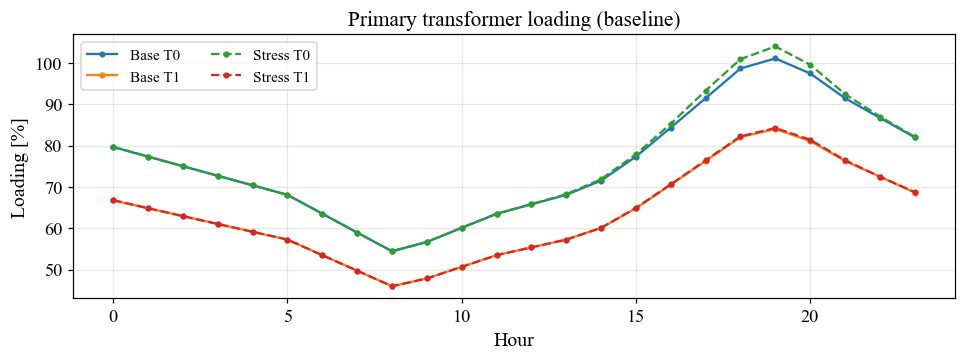

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for name, data, ls in [
    ("Base T0", trafo_base[:, 0], "-"),
    ("Base T1", trafo_base[:, 1], "-"),
    ("Stress T0", trafo_stress[:, 0], "--"),
    ("Stress T1", trafo_stress[:, 1], "--"),
]:
    ax.plot(hours, data, ls, marker="o", ms=3, label=name)

ax.set_xlabel("Hour")
ax.set_ylabel("Loading [%]")
ax.set_title("Primary transformer loading (baseline)")
ax.legend(ncol=2, loc="best")
fig.tight_layout()
savefig(fig, "supp_primary_trafo_loading.png")
plt.show()

## 5. Stress case: EV charging and Delta Loading

saved: /Users/savvaspanagi/Library/CloudStorage/OneDrive-CyprusUniversityofTechnology/Python-Matlab - Codes/Transformer Degradation Test/5th_Try_Base_Case/Benchmark Open Inputs/fig_out/supp_ev_and_delta_loading.png


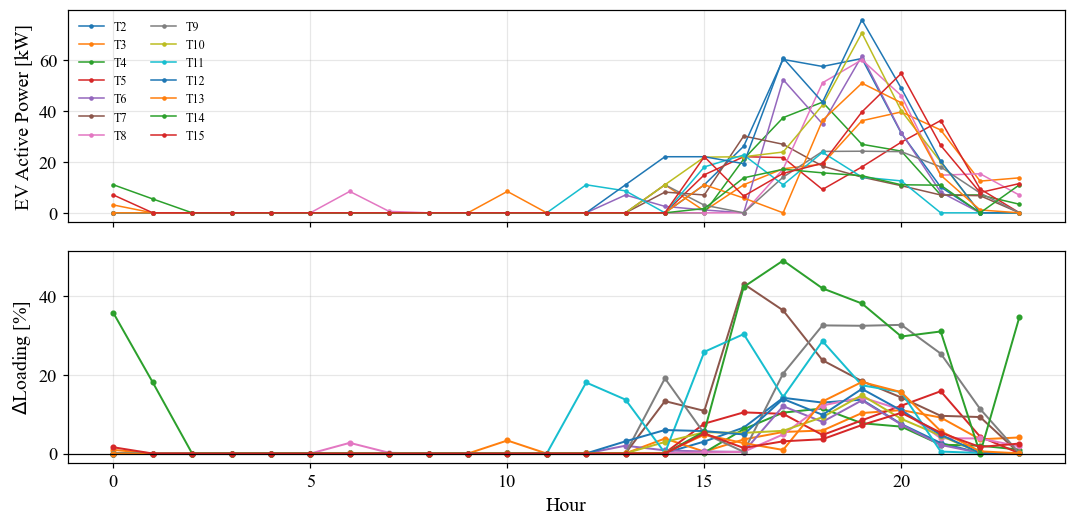

Peak total EV: 566.4 kW
Daily EV energy: 2646.0 kWh
Max ΔLoading: 49.0 %


In [9]:
sec_idxs = pd.read_csv(DATA / "secondary_trafo_idxs.csv")["secondary_trafo_idx"].to_numpy(dtype=int)

# EV = stress - base nodal P, summed per secondary (no separate EV CSV needed)
base_P = pd.read_csv(DATA / "base_load_P_mw.csv")
stress_P = pd.read_csv(DATA / "stress_load_P_mw.csv")
load_cols = [int(c.split("_", 1)[1]) for c in base_P.columns if c.startswith("load_")]
dP = stress_P[[f"load_{i}" for i in load_cols]].to_numpy(dtype=float) - base_P[[f"load_{i}" for i in load_cols]].to_numpy(dtype=float)
dP_df = pd.DataFrame(dP, columns=load_cols)

ev = np.zeros((n_steps, len(sec_idxs)), dtype=float)
for j, t_idx in enumerate(sec_idxs):
    served = trafo_to_loads.get(int(t_idx), [])
    if served:
        ev[:, j] = dP_df[served].sum(axis=1).to_numpy(dtype=float)

K_base = trafo_base[:, sec_idxs] / 100.0
K_stress = trafo_stress[:, sec_idxs] / 100.0
dK = 100.0 * (K_stress - K_base) / np.maximum(K_base, 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
for j, t_idx in enumerate(sec_idxs):
    axes[0].plot(hours, ev[:, j] * 1000.0, "-o", ms=2, lw=1, label=f"T{int(t_idx)}")
axes[0].set_ylabel("EV Active Power [kW]")
axes[0].legend(ncol=2, fontsize=8, frameon=False, loc="upper left")

for j, t_idx in enumerate(sec_idxs):
    axes[1].plot(hours, dK[:, j], "-o", ms=3, lw=1.3, label=f"T{int(t_idx)}")
axes[1].axhline(0.0, color="k", lw=0.8)
axes[1].set_ylabel(r"$\Delta$Loading [%]")
axes[1].set_xlabel("Hour")

fig.tight_layout()
savefig(fig, "supp_ev_and_delta_loading.png")
plt.show()

print(f"Peak total EV: {ev.sum(axis=1).max() * 1000:.1f} kW")
print(f"Daily EV energy: {ev.sum() * 1000:.1f} kWh")
print(f"Max ΔLoading: {dK.max():.1f} %")